In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/listings.csv")
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(699, 5)


,title,price,category,location,url
0,a louer appartement s +3 a soukra,1050.0,Appartements,Ariana,https://www.tayara.tn/item/appartements/ariana...
1,À Vendre – Appartement S+2 à Chotrana 1 (Les J...,390000.0,Appartements,tunis,https://www.tayara.tn/item/appartements/tunis/...
2,De magnifiques bureaux sur mesure pour 5 perso...,4349.0,Bureaux et Plateaux,Tunis,https://www.tayara.tn/item/bureaux-et-plateaux...
3,Immeuble en vente,665000.0,Appartements,Sousse,https://www.tayara.tn/item/appartements/sousse...
4,Villa indépendante en vente,375000.0,Maisons et Villas,Sousse,https://www.tayara.tn/item/maisons-et-villas/s...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   title     699 non-null    object 
 1   price     601 non-null    float64
 2   category  699 non-null    object 
 3   location  699 non-null    object 
 4   url       699 non-null    object 
dtypes: float64(1), object(4)
memory usage: 27.4+ KB


In [3]:
df['category'].value_counts()

category
Appartements                                 314
Bureaux et Plateaux                          137
Maisons et Villas                            102
Terrains et Fermes                            82
Magasins, Commerces et Locaux industriels     41
Locations de vacances                         14
Autres Immobiliers                             9
Name: count, dtype: int64

In [4]:
df['location'].value_counts().head(20)

location
Tunis         313
Ariana        111
tunis          80
Sousse         62
Ben Arous      55
Nabeul         37
Médenine        9
La Manouba      8
Sfax            8
Bizerte         7
Monastir        3
Mahdia          2
Kébili          1
Zaghouan        1
ariana          1
Béja            1
Name: count, dtype: int64

In [5]:
df['price'].describe()

count    6.010000e+02
mean     4.405495e+06
std      8.673678e+07
min      3.000000e+00
25%      1.200000e+03
50%      2.800000e+03
75%      2.150000e+05
max      2.100000e+09
Name: price, dtype: float64

In [6]:
apartments = df[df['category'] == 'Appartements'].copy()
print(apartments.shape)
apartments['price'].describe()

(314, 5)


count       292.000000
mean     108478.808219
std      159735.529250
min           3.000000
25%        1200.000000
50%        1800.000000
75%      225000.000000
max      665000.000000
Name: price, dtype: float64

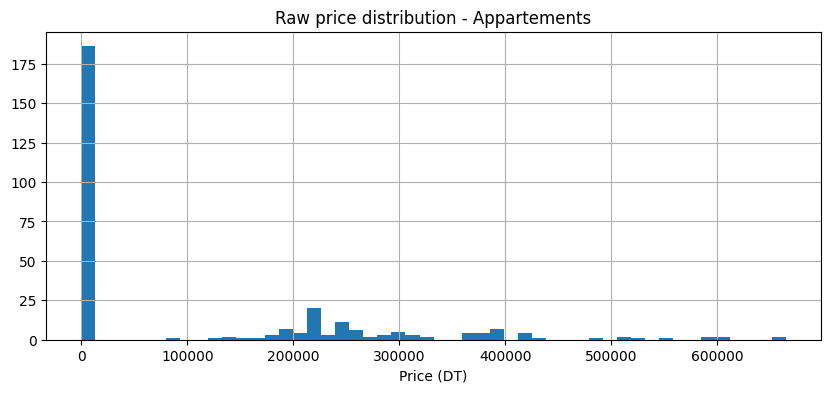

In [7]:
apartments['price'].hist(bins=50, figsize=(10,4))
plt.title("Raw price distribution - Appartements")
plt.xlabel("Price (DT)")
plt.show()

In [8]:
# See what's in the middle
print("Under 10,000 DT:", (apartments['price'] < 10_000).sum())
print("10,000 to 50,000 DT:", ((apartments['price'] >= 10_000) & (apartments['price'] < 50_000)).sum())
print("Over 50,000 DT:", (apartments['price'] >= 50_000).sum())

Under 10,000 DT: 186
10,000 to 50,000 DT: 0
Over 50,000 DT: 106


In [9]:
# Keep only plausible sale prices: between 30,000 and 5,000,000 DT
sale = apartments[(apartments['price'] >= 30_000) & (apartments['price'] <= 5_000_000)].copy()
print("Listings remaining after filter:", len(sale))
sale['price'].describe()


Listings remaining after filter: 106


count       106.000000
mean     296297.188679
std      121680.513236
min       80000.000000
25%      216250.000000
50%      250000.000000
75%      375250.000000
max      665000.000000
Name: price, dtype: float64

In [10]:
sale['location'] = sale['location'].str.strip().str.title()
sale['location'].value_counts().head(15)


location
Tunis        66
Sousse       20
Ariana       14
Ben Arous     4
Nabeul        2
Name: count, dtype: int64